<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 3</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Introduction to Data Science <br><br>
        <b>🧑‍💻 Implementer: Mohamad Reza Pirhadi</b><br><br>
        <h5 style="color: #1a365d;"> TASK 2 Implementation (Final Optimized Version)</h5>
    </p>
</div>

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading

In [17]:
train = pd.read_excel('train.xlsx')
test = pd.read_excel('test.xlsx')

X_train = train.drop(['shares', 'id'], axis=1)
y_train = train['shares']
test_ids = test['id']
X_test = test.drop('id', axis=1)

In [18]:
train.columns.tolist()

['id',
 'word_count',
 'unique_word_rate',
 'non_stop_rate',
 'link_count',
 'internal_link_count',
 'image_count',
 'video_count',
 'avg_word_length',
 'keyword_count',
 'content_subjectivity',
 'content_polarity',
 'positive_word_rate',
 'negative_word_rate',
 'avg_pos_polarity',
 'avg_neg_polarity',
 'title_subjectivity',
 'title_polarity',
 'topic_0_score',
 'topic_1_score',
 'topic_2_score',
 'topic_3_score',
 'shares',
 'publish_weekday',
 'channel',
 'is_weekend']

### 2. Outlier Clipping & Target Log Transform

In [ ]:
upper_limit = y_train.quantile(0.99)

y_train_clipped = np.clip(y_train, a_min=None, a_max=upper_limit)
y_train_log = np.log1p(y_train_clipped)

print(f"Original Max Shares: {y_train.max()}")
print(f"Clipped Max Shares: {y_train_clipped.max()}")

Original Max Shares: 10800
Clipped Max Shares: 9500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30130 entries, 0 to 30129
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    30130 non-null  int64  
 1   word_count            30130 non-null  int64  
 2   unique_word_rate      30130 non-null  float64
 3   non_stop_rate         30130 non-null  float64
 4   link_count            30130 non-null  int64  
 5   internal_link_count   30130 non-null  int64  
 6   image_count           30130 non-null  int64  
 7   video_count           29553 non-null  float64
 8   avg_word_length       29530 non-null  float64
 9   keyword_count         29519 non-null  float64
 10  content_subjectivity  30130 non-null  float64
 11  content_polarity      30130 non-null  float64
 12  positive_word_rate    30130 non-null  float64
 13  negative_word_rate    30130 non-null  float64
 14  avg_pos_polarity      30130 non-null  float64
 15  avg_neg_polarity   

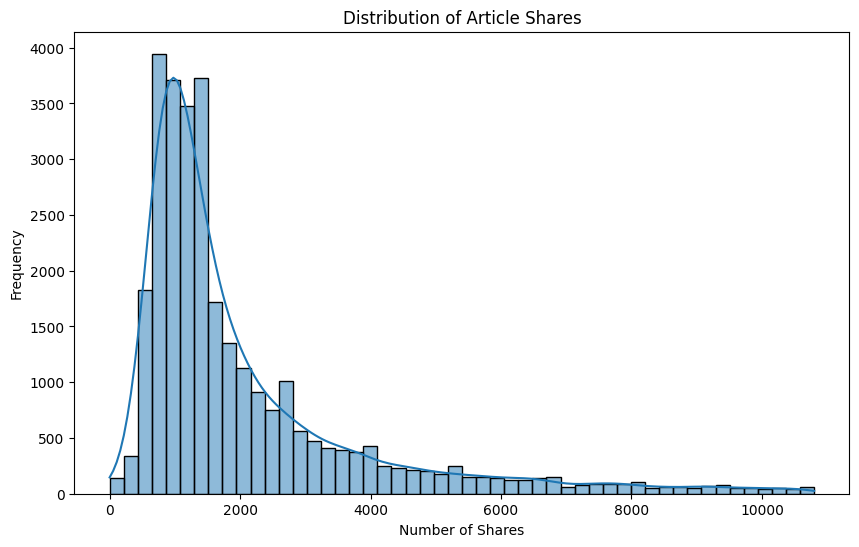

In [27]:
train.info()

missing_values = train.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0].sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.histplot(train['shares'], bins=50, kde=True)
plt.title('Distribution of Article Shares')
plt.xlabel('Number of Shares')
plt.ylabel('Frequency')
plt.show()

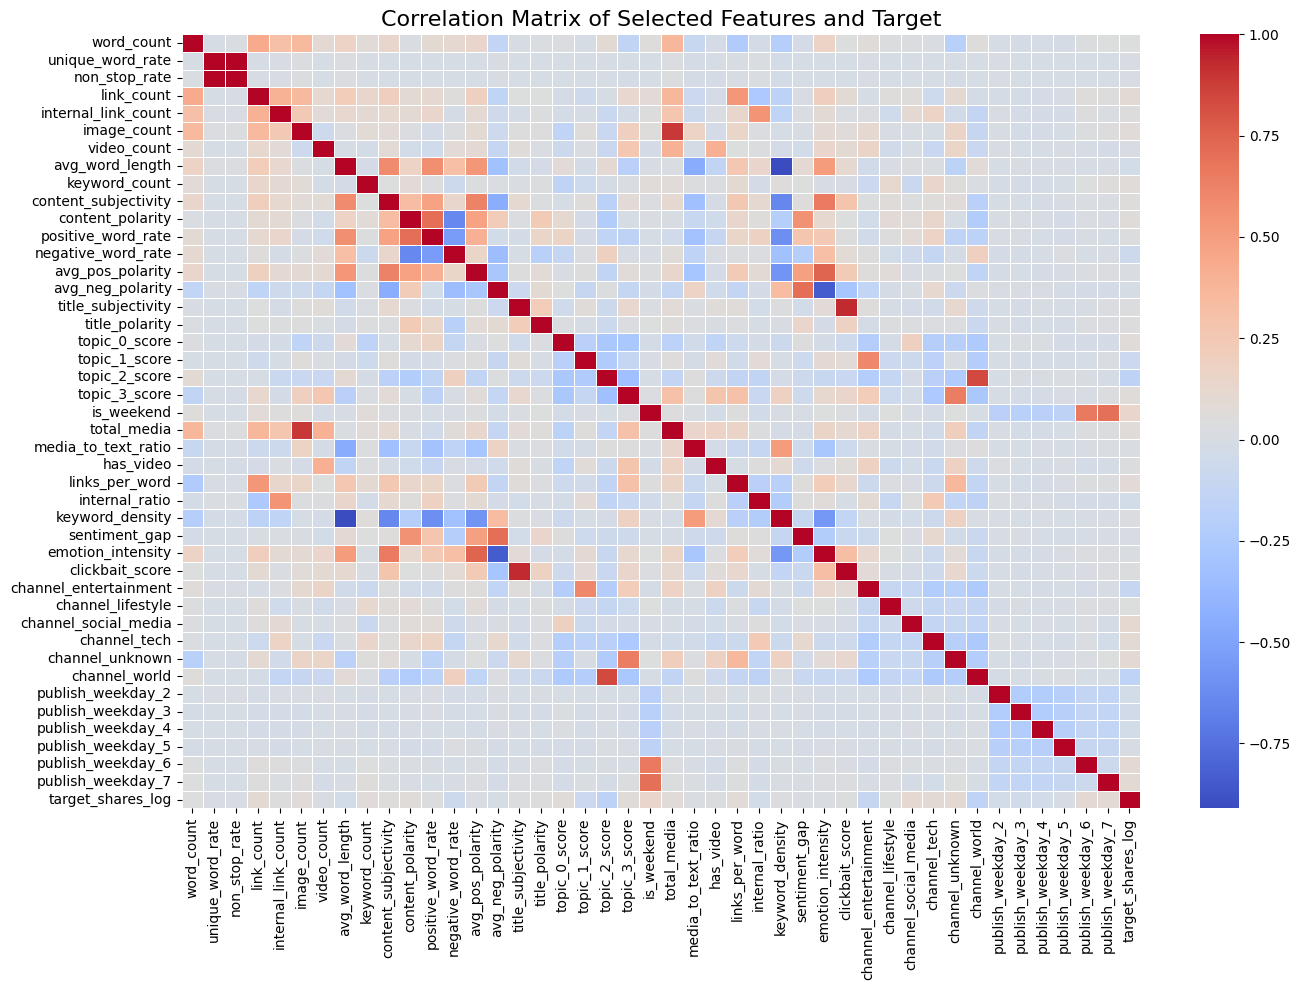

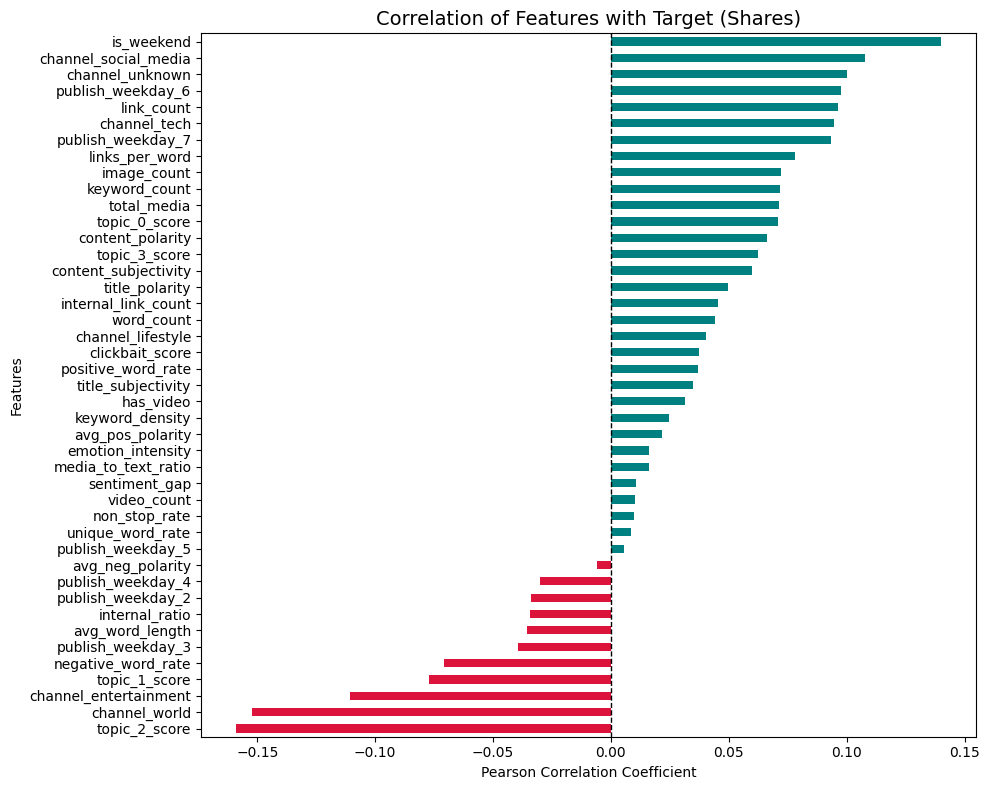

In [28]:

df_for_corr = X_train_selected.copy()
df_for_corr['target_shares_log'] = y_train_log

corr_matrix = df_for_corr.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Matrix of Selected Features and Target', fontsize=16)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 8))

target_corr = corr_matrix['target_shares_log'].drop('target_shares_log').sort_values()

target_corr.plot(kind='barh', color=np.where(target_corr > 0, 'teal', 'crimson'))
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title('Correlation of Features with Target (Shares)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 3. Leakage-Free Imputation

In [20]:
cols_with_missing = ['keyword_count', 'avg_word_length', 'title_subjectivity', 'video_count']
for col in cols_with_missing:
    if col in X_train.columns:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

### 4. Advanced Feature Engineering & Encoding

In [21]:
for df in [X_train, X_test]:
    df['total_media'] = df['image_count'] + df['video_count']
    df['media_to_text_ratio'] = df['total_media'] / (df['word_count'] + 1)
    df['has_video'] = (df['video_count'] > 0).astype(int)
    
    df['links_per_word'] = df['link_count'] / (df['word_count'] + 1)
    if 'internal_link_count' in df.columns:
        df['internal_ratio'] = df['internal_link_count'] / (df['link_count'] + 1)
    df['keyword_density'] = df['keyword_count'] / (df['word_count'] + 1)
    
    if 'avg_pos_polarity' in df.columns and 'avg_neg_polarity' in df.columns:
        df['sentiment_gap'] = df['avg_pos_polarity'] - np.abs(df['avg_neg_polarity'])
        df['emotion_intensity'] = df['avg_pos_polarity'] + np.abs(df['avg_neg_polarity'])
        
        if 'title_subjectivity' in df.columns:
            df['clickbait_score'] = df['title_subjectivity'] * df['emotion_intensity']
            
cols_to_encode = ['channel']
if 'publish_weekday' in X_train.columns:
    cols_to_encode.append('publish_weekday')

X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train_selected = X_train.copy()
X_test_selected = X_test.copy()

print(f"Total features used: {X_train_selected.shape[1]}")

Total features used: 43


### 5. XGBoost Tuning

In [22]:
print("Starting XGBoost Tuning...")
param_grid_xgb = {
    'n_estimators': [500, 800, 1000, 1200],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 7],
    'gamma': [0.1, 0.5, 1, 2]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=25, 
    scoring='neg_mean_squared_error', 
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_xgb.fit(X_train_selected, y_train_log)
print("Best XGBoost Params:", random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

Starting XGBoost Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best XGBoost Params: {'subsample': 0.9, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


### 6. LightGBM Tuning

In [23]:
print("\nStarting LightGBM Tuning...")
param_grid_lgb = {
    'n_estimators': [500, 800, 1000, 1200],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [6, 8, -1],
    'num_leaves': [31, 63, 127],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
random_search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid_lgb,
    n_iter=25,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search_lgb.fit(X_train_selected, y_train_log)
print("Best LightGBM Params:", random_search_lgb.best_params_)
best_lgb = random_search_lgb.best_estimator_


Starting LightGBM Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best LightGBM Params: {'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


### 7. Dynamic Weighted Ensemble & Evaluation

In [24]:
mse_xgb = -random_search_xgb.best_score_
mse_lgb = -random_search_lgb.best_score_

weight_xgb = (1 / mse_xgb) / ((1 / mse_xgb) + (1 / mse_lgb))
weight_lgb = 1.0 - weight_xgb
print(f"\n[Dynamic Weights] XGBoost: {weight_xgb:.2f} | LightGBM: {weight_lgb:.2f}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmsle_scores_ensemble = []

for train_index, val_index in kf.split(X_train_selected):
    X_fold_train, X_fold_val = X_train_selected.iloc[train_index], X_train_selected.iloc[val_index]
    y_fold_train_log = y_train_log.iloc[train_index]
    y_fold_val_actual = y_train.iloc[val_index] 
    
    best_xgb.fit(X_fold_train, y_fold_train_log)
    best_lgb.fit(X_fold_train, y_fold_train_log)
    
    pred_xgb_log = best_xgb.predict(X_fold_val)
    pred_lgb_log = best_lgb.predict(X_fold_val)
    
    ensemble_pred_log = (weight_xgb * pred_xgb_log) + (weight_lgb * pred_lgb_log)
    ensemble_pred = np.maximum(np.expm1(ensemble_pred_log), 0)
    
    score = np.sqrt(mean_squared_log_error(y_fold_val_actual, ensemble_pred))
    rmsle_scores_ensemble.append(score)

print(f"\nMean CV RMSLE (Weighted Ensemble): {np.mean(rmsle_scores_ensemble):.4f}")


[Dynamic Weights] XGBoost: 0.50 | LightGBM: 0.50

Mean CV RMSLE (Weighted Ensemble): 0.6873


### 8. Final Submission

In [25]:
best_xgb.fit(X_train_selected, y_train_log)
best_lgb.fit(X_train_selected, y_train_log) 

test_preds_log_xgb = best_xgb.predict(X_test_selected)
test_preds_log_lgb = best_lgb.predict(X_test_selected)

ensemble_preds_log = (test_preds_log_xgb + test_preds_log_lgb) / 2.0

final_test_preds = np.maximum(np.expm1(ensemble_preds_log), 0)

submission_ensemble = pd.DataFrame({'id': test_ids, 'shares': final_test_preds})
submission_ensemble.to_csv('submission_ensemble_final.csv', index=False)

print("\nFinal Ensemble submission file generated successfully!")


Final Ensemble submission file generated successfully!


### 9. Feature Importance Visualization

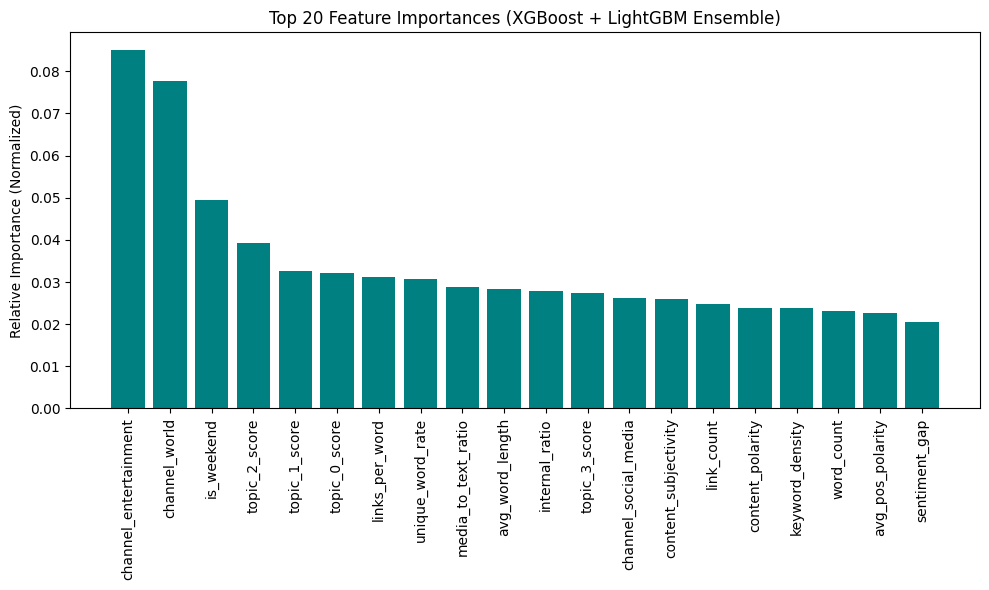

In [26]:


importances_xgb = best_xgb.feature_importances_
importances_lgb = best_lgb.feature_importances_

importances_xgb_norm = importances_xgb / importances_xgb.sum()
importances_lgb_norm = importances_lgb / importances_lgb.sum()

avg_importance = (weight_xgb * importances_xgb_norm) + (weight_lgb * importances_lgb_norm)

indices = np.argsort(avg_importance)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.title("Top 20 Feature Importances (XGBoost + LightGBM Ensemble)")
plt.bar(range(20), avg_importance[indices], align="center", color='teal')
plt.xticks(range(20), [X_train_selected.columns[i] for i in indices], rotation=90)
plt.ylabel('Relative Importance (Normalized)')
plt.tight_layout()
plt.show()